In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Add bias term
X_bias = np.hstack([np.ones((X.shape[0], 1)), X])

# Locally Weighted Linear Regression function
def lwlr(query_point, X, y, tau=0.5):
    """
    query_point: 1x2 array including bias term [1, x_query]
    X: nx2 array with bias term
    y: nx1 array of outputs
    tau: bandwidth parameter (controls weighting)
    """
    m = X.shape[0]
    W = np.eye(m)
    
    # Compute weights
    for i in range(m):
        diff = query_point - X[i]
        W[i, i] = np.exp(- (diff @ diff.T) / (2 * tau**2))
    
    # Closed-form solution for weighted linear regression
    XTWX = X.T @ W @ X
    if np.linalg.det(XTWX) == 0.0:
        theta = np.linalg.pinv(XTWX) @ X.T @ W @ y
    else:
        theta = np.linalg.inv(XTWX) @ X.T @ W @ y
    
    # Prediction for query point
    y_pred = query_point @ theta
    return y_pred

In [31]:
# Generate sample data
np.random.seed(41)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X) + 0.5 * X + np.random.randn(100, 1) * 0.3

In [32]:
# Predict for all points
y_pred = np.array([lwlr(np.array([1, x]), X_bias, y, tau=0.3) for x in X.flatten()])

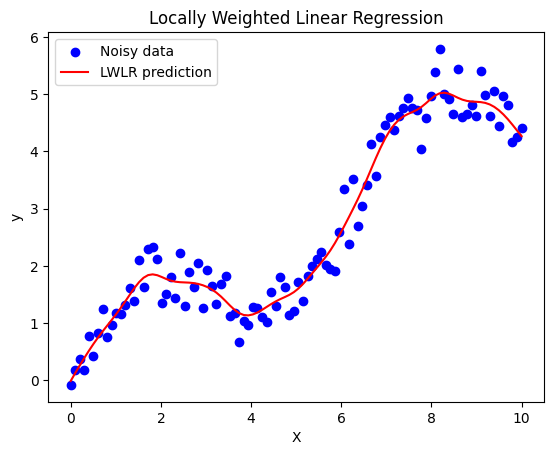

In [33]:
# Plot results
plt.scatter(X, y, color='blue', label='Noisy data')
plt.plot(X, y_pred, color='red', label='LWLR prediction')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Locally Weighted Linear Regression')
plt.legend()
plt.show()